In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt

In [2]:
files = glob.glob('/home/ybadoux/AMUSE/300k_runs/*.npy')
files.sort()
files

['/home/ybadoux/AMUSE/300k_runs/nbounds_rmin4.45_rmax13.35.npy',
 '/home/ybadoux/AMUSE/300k_runs/nbounds_rmin7.0_rmax12.0.npy',
 '/home/ybadoux/AMUSE/300k_runs/times_rmin4.45_rmax13.35.npy',
 '/home/ybadoux/AMUSE/300k_runs/times_rmin7.0_rmax12.0.npy']

4.45 13.35
7.0 12.0


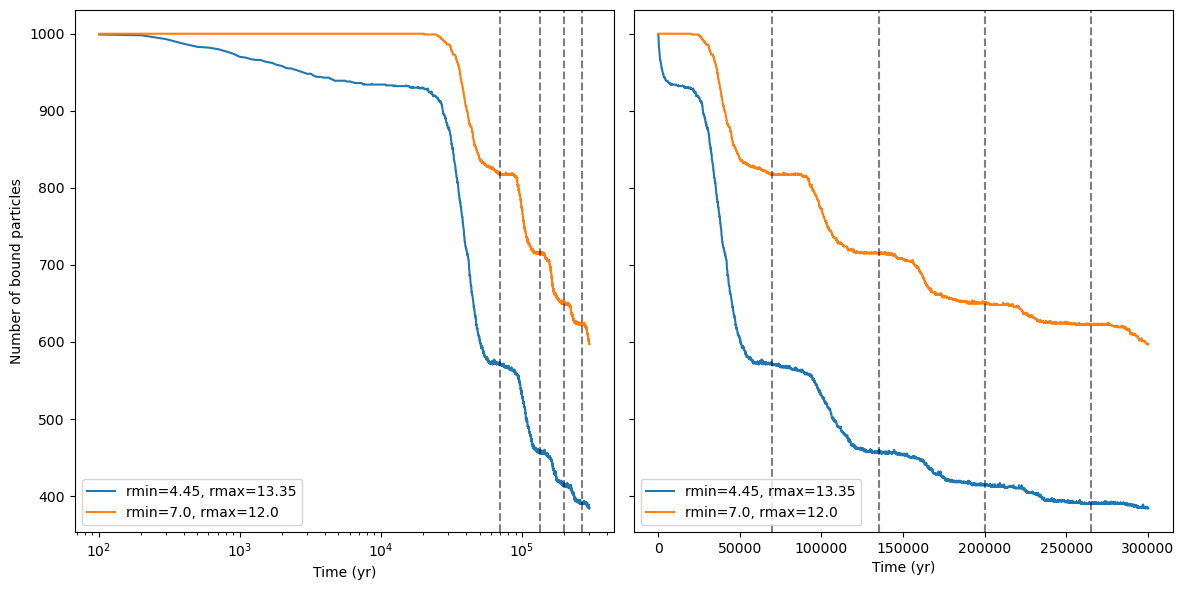

In [3]:
fig, (ax0,ax1) = plt.subplots(1,2,figsize=(12,6), sharey=True)

r_disks = []
nbounds = []
times_list = []
diffs = []

for i in range(len(files)//2):
    nbound = np.load(files[i])
    times = np.load(files[i+len(files)//2])
    rmin = files[i].split('/')[-1].split('rmin')[1].split('_')[0]
    rmax = files[i].split('/')[-1].split('rmax')[1].split('.npy')[0]
    r_disks.append((rmin, rmax))
    nbounds.append(nbound)
    times_list.append(times)
    diffs.append(np.diff(nbound))
    print(rmin, rmax)

    ax0.plot(times, nbound, label=f'rmin={rmin}, rmax={rmax}')
    ax1.plot(times, nbound, label=f'rmin={rmin}, rmax={rmax}')

plateau_times = []
t=70000
while t < 300000:
    plateau_times.append(t)
    ax0.axvline(t, color='k', linestyle='--', alpha=0.5)
    ax1.axvline(t, color='k', linestyle='--', alpha=0.5)
    t += 65000
ax0.set_xscale('log')
# ax1.set_yscale('log')
ax0.legend()
ax1.legend()
ax0.set_xlabel('Time (yr)')
ax1.set_xlabel('Time (yr)')
ax0.set_ylabel('Number of bound particles')

plt.tight_layout()
plt.show()

In [4]:
plateau_times = np.array(plateau_times)
print(plateau_times)
#find time closest to plateau_times
def find_closest_time(times, target_times, nbound):
    closest_times = []
    nbounds = []
    for target in target_times:
        idx = (np.abs(times - target)).argmin()
        closest_times.append(times[idx])
        nbounds.append(nbound[idx])
    return np.array(closest_times), np.array(nbounds)
closest_times, n_plateau0 = find_closest_time(times_list[0], plateau_times, nbounds[0])
print(closest_times, n_plateau0)
closest_times, n_plateau1 = find_closest_time(times_list[1], plateau_times, nbounds[1])
print(closest_times, n_plateau1)

[ 70000 135000 200000 265000]
[ 70046.44657534 134989.51232877 200032.64383562 264976.70958904] [571 456 414 390]
[ 70046.44657534 134989.51232877 200032.64383562 264976.70958904] [817 714 651 622]


In [5]:
print(np.diff(n_plateau0), np.diff(n_plateau1))
frac_diffs = []
for i in range(len(plateau_times)-1):
    #fractional difference
    print(f'plateau {i} to plateau {i+1}:',n_plateau0[i+1]/n_plateau0[i], n_plateau1[i+1]/n_plateau1[i])
    frac_diffs.append(n_plateau0[i+1]/n_plateau0[i])
    frac_diffs.append(n_plateau1[i+1]/n_plateau1[i])
print('Mean fractional difference:', np.mean(frac_diffs))

    

[-115  -42  -24] [-103  -63  -29]
plateau 0 to plateau 1: 0.7985989492119089 0.8739290085679314
plateau 1 to plateau 2: 0.9078947368421053 0.9117647058823529
plateau 2 to plateau 3: 0.9420289855072463 0.9554531490015361
Mean fractional difference: 0.8982782558355135


[1.11637689e+00 2.04500343e-06] [1.08799366e+00 1.45146543e-06]


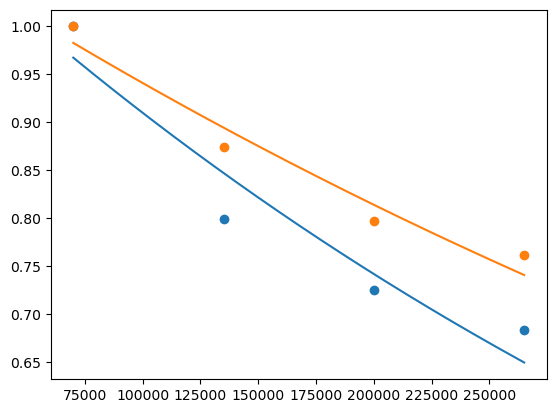

In [6]:
plt.scatter(plateau_times, n_plateau0/n_plateau0[0], label='rmin=0.1, rmax=0.2')
plt.scatter(plateau_times, n_plateau1/n_plateau1[0], label='rmin=0.2, rmax=0.3')
def exponential_decay(t, a, b):
    return a * np.exp(-b * t)
from scipy.optimize import curve_fit
# Fit the data to an exponential decay model

popt0, pcov0 = curve_fit(exponential_decay, plateau_times, n_plateau0/n_plateau0[0], p0=(0.9, 1/60000))
popt1, pcov1 = curve_fit(exponential_decay, plateau_times, n_plateau1/n_plateau1[0], p0=(0.9, 1/60000))
t_fit = np.linspace(plateau_times[0], plateau_times[-1], 1000)
plt.plot(t_fit, exponential_decay(t_fit, *popt0), label='Fit rmin=0.1, rmax=0.2', color='C0')
plt.plot(t_fit, exponential_decay(t_fit, *popt1), label='Fit rmin=0.2, rmax=0.3', color='C1')
print(popt0, popt1)

42 42
42 42


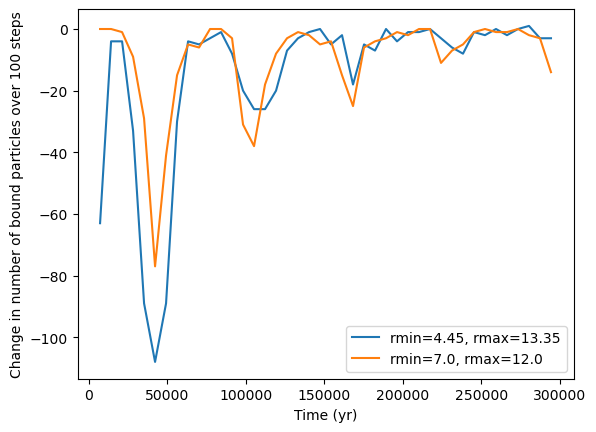

[  7104.70958904  14110.35616438  21114.          28118.64383562
  35123.29041096  42127.93424658  49132.57808219  56137.22465753
  63141.86849315  70146.51506849  77151.15890411  84155.80273973
  91160.44931507  98165.09315068 105169.73972603 112174.38356164
 119179.02739726 126183.6739726  133188.31780822 140192.96438356
 147197.60821918 154202.25205479 161206.89863014 168211.54246575
 175216.1890411  182220.83287671 189225.47671233 196230.12328767
 203234.76712329 210239.41369863 217244.05753425 224248.70136986
 231253.34794521 238257.99178082 245262.63561644 252267.28219178
 259272.92876712 266277.57260274 273282.21643836 280286.8630137
 287291.50684932 294296.15068493]


In [7]:
# look for big drops in the number of bound particles
for i in range(len(nbounds)):
    diff_100 = np.diff(nbounds[i][::70])
    times100 = times_list[i][::70]
    times100 = times100[1:]  # Adjust for the diff length
    print(len(diff_100), len(times100))
    plt.plot(times100,diff_100, label=f'rmin={r_disks[i][0]}, rmax={r_disks[i][1]}')
plt.legend()
plt.xlabel('Time (yr)')
plt.ylabel('Change in number of bound particles over 100 steps')
plt.show()
print(times100)

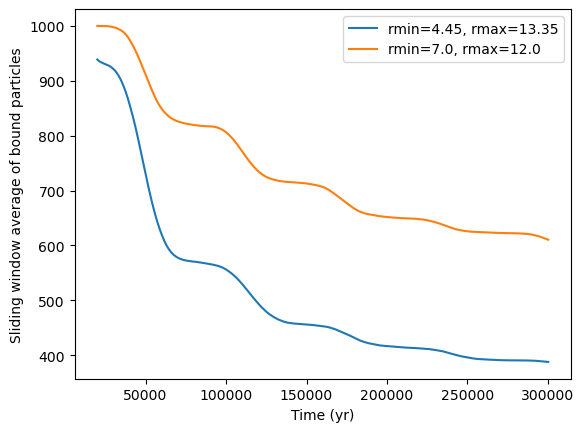

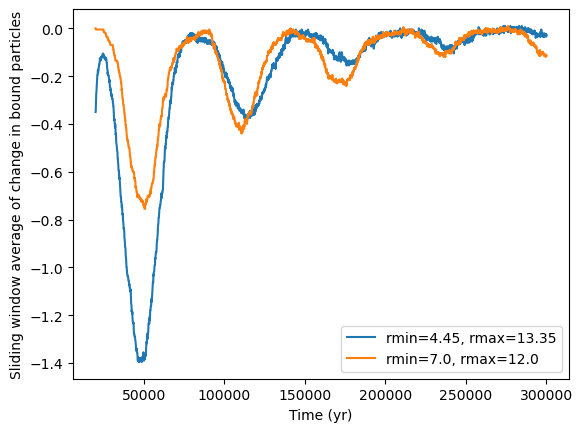

In [8]:
#compute sliding window average of the number of bound particles
def sliding_window_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')
window_size = 200
for i in range(len(nbounds)):
    nbound_avg = sliding_window_average(nbounds[i], window_size)
    times_avg = times_list[i][window_size-1:]  # Adjust for the average length
    plt.plot(times_avg, nbound_avg, label=f'rmin={r_disks[i][0]}, rmax={r_disks[i][1]}')
plt.legend()
plt.xlabel('Time (yr)')
plt.ylabel('Sliding window average of bound particles')
plt.show()

#compute sliding window average of the change in number of bound particles
diffs_avg = []
for i in range(len(diffs)):
    diff_avg = sliding_window_average(diffs[i], window_size)
    times_avg = times_list[i][window_size:]  # Adjust for the average length
    diffs_avg.append(diff_avg)
    plt.plot(times_avg, diff_avg, label=f'rmin={r_disks[i][0]}, rmax={r_disks[i][1]}')
plt.legend()
plt.xlabel('Time (yr)')
plt.ylabel('Sliding window average of change in bound particles')
plt.show()

In [18]:
print(times_avg)

[ 20114.3369863   20214.40273973  20314.46849315 ... 299999.93424658
 300100.         300200.06575342]


Time: 46831.05205479452, Change: -1.3950000000000002
Time: 114275.77808219178, Change: -0.385
Time: 176016.71780821917, Change: -0.155
Time: 242660.91232876712, Change: -0.10500000000000002
Time: 293495.6219178082, Change: -0.039999999999999994


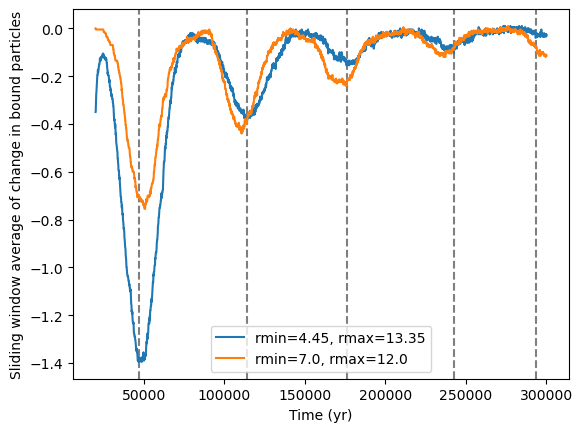

Drop times: [np.float64(46831.05205479452), np.float64(114275.77808219178), np.float64(176016.71780821917), np.float64(242660.91232876712), np.float64(293495.6219178082)]
65276.62009132421


In [24]:
#get the times of the biggest in 70kyr windows
t=0
drop_times = []
while t < np.max(times_avg):
    #get all indices between t and t+70000
    indices = np.where((times_avg >= t) & (times_avg < t + 70000))[0]
    if len(indices) > 0:
        min_index = indices[np.argmin(diffs_avg[0][indices])]
        print(f'Time: {times_avg[min_index]}, Change: {diffs_avg[0][min_index]}')
        plt.axvline(times_avg[min_index], color='k', linestyle='--', alpha=0.5)
        drop_times.append(times_avg[min_index])
    t += 70000

#compute sliding window average of the change in number of bound particles
diffs_avg = []
for i in range(len(diffs)):
    diff_avg = sliding_window_average(diffs[i], window_size)
    times_avg = times_list[i][window_size:]  # Adjust for the average length
    diffs_avg.append(diff_avg)
    plt.plot(times_avg, diff_avg, label=f'rmin={r_disks[i][0]}, rmax={r_disks[i][1]}')
plt.legend()
plt.xlabel('Time (yr)')
plt.ylabel('Sliding window average of change in bound particles')
plt.show()

print("Drop times:", drop_times)
print(np.mean(np.diff(drop_times[:-1])))

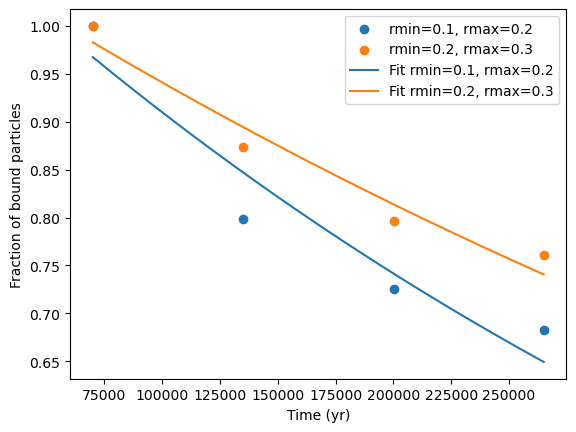

[1.11648728e+00 5.25973389e+04] [1.08807731e+00 7.41034019e+04]


In [ ]:
from amuse.units import units
def decay_function(t):
    return 1.6e6 | units.Msun * 0.898 ** (t / 65000 | units.yr)  # Adjusted to match the decay rate

disk_lifetime = 2.7e6 #yr



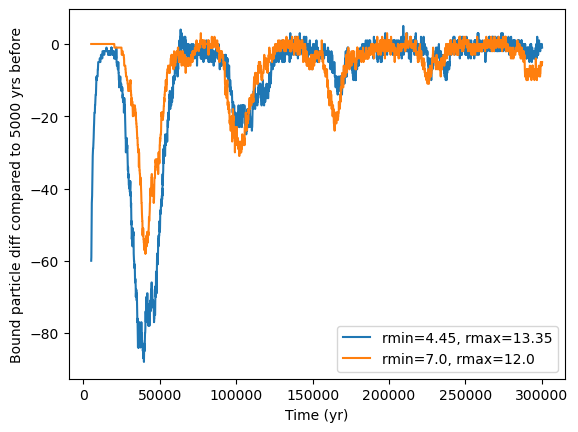

In [10]:
diffs_50s = []
#compute difference in bound particles compared to 50 steps before
for i in range(len(nbounds)):
    diffs_50 = []
    for j in range(1, len(nbounds[i])):
        if j >= 50:
            diff = nbounds[i][j] - nbounds[i][j-50]
            diffs_50.append(diff)
    diffs_50s.append(diffs_50)

plt.plot(times_list[0][50:], diffs_50s[0], label=f'rmin={r_disks[0][0]}, rmax={r_disks[0][1]}')
plt.plot(times_list[1][50:], diffs_50s[1], label=f'rmin={r_disks[1][0]}, rmax={r_disks[1][1]}')
plt.legend()
plt.xlabel('Time (yr)')
plt.ylabel('Bound particle diff compared to 5000 yrs before')
plt.show()

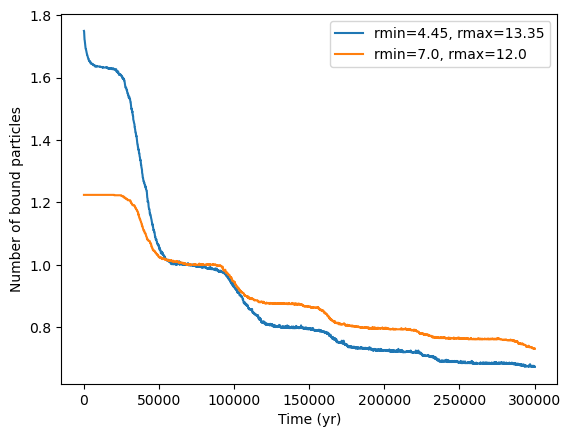

In [11]:
#fit exponential decay to the number of bound particles
def func(t, M0, x, tau = int(60*1e3)):
    return M0 * x**(t // tau)

N_function = []

plt.plot(times_list[0], nbounds[0]/n_plateau0[0], label=f'rmin={r_disks[0][0]}, rmax={r_disks[0][1]}')
plt.plot(times_list[1], nbounds[1]/n_plateau1[0], label=f'rmin={r_disks[1][0]}, rmax={r_disks[1][1]}')
plt.legend()
plt.xlabel('Time (yr)')
plt.ylabel('Number of bound particles')
plt.show()